## Importing Dataset & libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('stocks_cleaned.csv')

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,Ticker
0,2015-01-02,24.648441,24.659506,23.754468,24.192604,212818400,AAPL
1,2015-01-05,23.962477,24.042138,23.325190,23.511065,257142000,AAPL
2,2015-01-06,23.575235,23.772175,23.152589,23.513277,263188400,AAPL
3,2015-01-07,23.721278,23.942559,23.610638,23.842983,160423600,AAPL
4,2015-01-08,24.170475,24.816614,24.053195,24.759081,237458000,AAPL


## Data_Information

In [4]:
df.shape

(16590, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16590 entries, 0 to 16589
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    16590 non-null  object 
 1   Open    16590 non-null  float64
 2   High    16590 non-null  float64
 3   Low     16590 non-null  float64
 4   Close   16590 non-null  float64
 5   Volume  16590 non-null  int64  
 6   Ticker  16590 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 907.4+ KB


In [6]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Ticker    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
Ticker            object
dtype: object

In [10]:
df = df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

In [11]:
df.groupby("Ticker").size()

Ticker
AAPL    2765
AMZN    2765
JNJ     2765
JPM     2765
MSFT    2765
TSLA    2765
dtype: int64

In [12]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,16590,16590.000000,16590.000000,16590.000000,16590.000000,1.659000e+04
mean,2020-06-29 19:22:56.202531328,133.638265,135.196462,132.027506,133.665102,5.756266e+07
min,2015-01-02 00:00:00,9.488000,10.331333,9.403333,9.578000,2.114900e+06
25%,2017-09-29 00:00:00,53.096662,53.667500,52.521489,53.072763,1.272322e+07
50%,2020-06-30 00:00:00,114.842190,116.014845,113.589937,114.813435,3.782415e+07
75%,2023-03-29 00:00:00,175.448028,177.496020,173.699997,175.366795,8.225008e+07
max,2025-12-30 00:00:00,550.830123,551.048411,537.366702,538.658508,9.140820e+08
std,NaN,98.769782,100.028558,97.422034,98.759562,6.176054e+07


## EDA

In [13]:
print("Shape :", df.shape)

print("\nTickers:")
print(df["Ticker"].unique())

print("\nDate Range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nRows per Company")
print(df["Ticker"].value_counts())

Shape : (16590, 7)

Tickers:
['AAPL' 'AMZN' 'JNJ' 'JPM' 'MSFT' 'TSLA']

Date Range:
2015-01-02 00:00:00 to 2025-12-30 00:00:00

Rows per Company
Ticker
AAPL    2765
AMZN    2765
JNJ     2765
JPM     2765
MSFT    2765
TSLA    2765
Name: count, dtype: int64


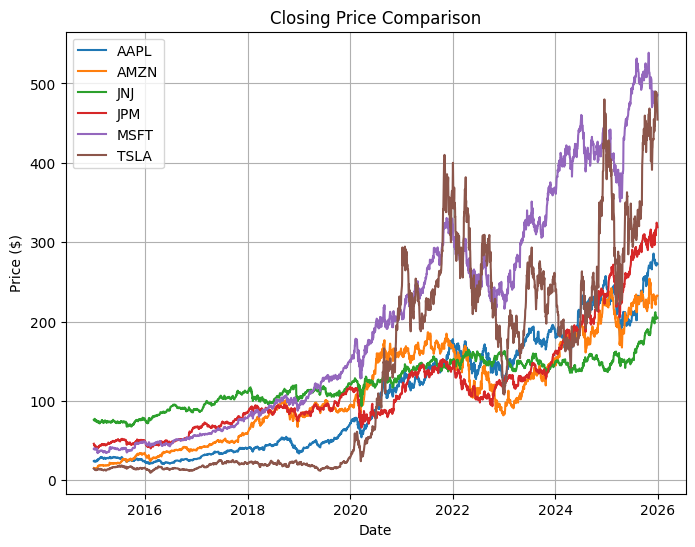

In [14]:
plt.figure(figsize=(8,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"]==ticker]

    plt.plot(
        temp["Date"],
        temp["Close"],
        label=ticker
    )

plt.legend()

plt.title("Closing Price Comparison")

plt.xlabel("Date")

plt.ylabel("Price ($)")

plt.grid()

plt.show()

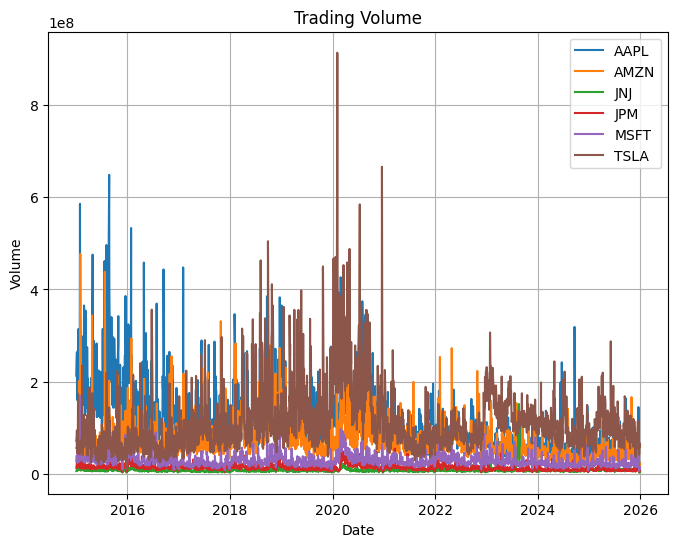

In [16]:
plt.figure(figsize=(8,6))

for ticker in df["Ticker"].unique():

    temp = df[df["Ticker"]==ticker]

    plt.plot(
        temp["Date"],
        temp["Volume"],
        label=ticker
    )

plt.legend()

plt.title("Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid()

plt.show()

In [ ]:
df["Return"] = df.groupby("Ticker")["Close"].pct_change()

plt.figure(figsize=(15,6))

for ticker in df["Ticker"].unique():

    temp=df[df["Ticker"]==ticker]

    plt.plot(
        temp["Date"],
        temp["Return"],
        alpha=0.6
    )

plt.title("Daily Returns")

plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(
    df["Return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [ ]:
df["Volatility"] = (
    df
    .groupby("Ticker")["Return"]
    .rolling(20)
    .std()
    .reset_index(level=0,drop=True)
)

plt.figure(figsize=(15,8))

for ticker in df["Ticker"].unique():

    temp=df[df["Ticker"]==ticker]

    plt.plot(
        temp["Date"],
        temp["Volatility"],
        label=ticker
    )

plt.legend()

plt.title("20-Day Rolling Volatility")

plt.grid()

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Ticker",
    y="Return"
)

plt.title("Return Distribution by Company")

plt.show()

In [ ]:
close_prices = df.pivot(
    index="Date",
    columns="Ticker",
    values="Close"
)

corr = close_prices.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
returns = close_prices.pct_change()

cumulative = (1 + returns).cumprod()

plt.figure(figsize=(8,6))

for column in cumulative.columns:

    plt.plot(
        cumulative.index,
        cumulative[column],
        label=column
    )

plt.legend()

plt.title("Cumulative Returns")

plt.grid()

plt.show()

## Feature_Engineering

In [ ]:
pip install ta

In [ ]:
from ta.trend import EMAIndicator
from ta.trend import SMAIndicator
from ta.trend import MACD

from ta.momentum import RSIIndicator

from ta.volatility import AverageTrueRange
from ta.volatility import BollingerBands

In [ ]:
def create_features(stock_df):

    df = stock_df.copy()

    return df

### Returns

In [ ]:
df["Return"] = df["Close"].pct_change()                                 #Daily Return

In [ ]:
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))           #Log Return

### Trend_indicators

In [ ]:
df["SMA10"] = SMAIndicator(
    close=df["Close"],
    window=10
).sma_indicator()

In [ ]:
df["SMA20"] = SMAIndicator(
    close=df["Close"],
    window=20
).sma_indicator()

In [ ]:
df["EMA20"] = EMAIndicator(
    close=df["Close"],
    window=20
).ema_indicator()

In [ ]:
df["EMA50"] = EMAIndicator(
    close=df["Close"],
    window=50
).ema_indicator()

### Momentum

In [ ]:
df["RSI"] = RSIIndicator(
    close=df["Close"],
    window=14
).rsi()

In [ ]:
macd = MACD(df["Close"])

df["MACD"] = macd.macd()

df["MACD_Signal"] = macd.macd_signal()

df["MACD_Hist"] = macd.macd_diff()

### Volatality

In [ ]:
atr = AverageTrueRange(
    high=df["High"],
    low=df["Low"],
    close=df["Close"]
)

df["ATR"] = atr.average_true_range()

In [ ]:
bb = BollingerBands(df["Close"])

df["BB_High"] = bb.bollinger_hband()

df["BB_Low"] = bb.bollinger_lband()

df["BB_Mid"] = bb.bollinger_mavg()

### Candle_Stick Features

In [ ]:
df["Body"] = abs(df["Close"] - df["Open"])

df["Upper_Shadow"] = (
    df["High"] -
    df[["Open","Close"]].max(axis=1)
)

df["Lower_Shadow"] = (
    df[["Open","Close"]].min(axis=1)
    - df["Low"]
)

df["Range"] = df["High"] - df["Low"]

### Integrating_features

In [ ]:
df = df.dropna().reset_index(drop=True)

In [ ]:
df.head()

In [ ]:
processed_data = {}

for ticker in df["Ticker"].unique():

    stock_df = df[df["Ticker"] == ticker].copy()

    processed_data[ticker] = create_features(stock_df)

    processed_data[ticker] = stock_df

In [ ]:
processed_data["AAPL"].head()

In [ ]:
processed_data["AAPL"].info()
processed_data["AAPL"].head()

In [ ]:
print(processed_data)

## Train_test_split

In [ ]:
train_data = {}
val_data = {}
test_data = {}

In [ ]:
for ticker, stock_df in processed_data.items():

    train_data[ticker] = stock_df[
        stock_df["Date"] < "2023-01-01"
    ].copy()

    val_data[ticker] = stock_df[
        (stock_df["Date"] >= "2023-01-01") &
        (stock_df["Date"] < "2024-01-01")
    ].copy()

    test_data[ticker] = stock_df[
        stock_df["Date"] >= "2024-01-01"
    ].copy()

In [ ]:
for ticker in train_data:

    print(f"\n{ticker}")

    print("Train:", train_data[ticker].shape)

    print("Validation:", val_data[ticker].shape)

    print("Test:", test_data[ticker].shape)

In [ ]:
feature_columns = [
    col for col in train_data["AAPL"].columns
    if col not in ["Date", "Ticker"]
]

In [ ]:
print(feature_columns)

### Scaling features

In [ ]:
from sklearn.preprocessing import StandardScaler

scalers = {}

for ticker in train_data:

    scaler = StandardScaler()

    train_data[ticker][feature_columns] = scaler.fit_transform(
        train_data[ticker][feature_columns]
    )

    val_data[ticker][feature_columns] = scaler.transform(
        val_data[ticker][feature_columns]
    )

    test_data[ticker][feature_columns] = scaler.transform(
        test_data[ticker][feature_columns]
    )

    scalers[ticker] = scaler

In [ ]:
train_data["AAPL"][feature_columns].describe().T

## Exporting

In [ ]:
combined_df = pd.concat(
    processed_data.values(),
    ignore_index=True
)

combined_df.to_csv("processed_stock_data.csv", index=False)

In [ ]:
processed_data.keys()

In [ ]:
import os

os.makedirs("processed_data", exist_ok=True)

for ticker, df in processed_data.items():
    df.to_csv(f"processed_data/{ticker}.csv", index=False)

print("All files saved successfully!")

In [ ]:
import os
import pandas as pd

stocks = ["AAPL", "AMZN", "JNJ", "JPM", "MSFT", "TSLA"]

os.makedirs("processed_data/train", exist_ok=True)
os.makedirs("processed_data/test", exist_ok=True)

for stock in stocks:

    df = pd.read_csv(f"processed_data/{stock}.csv")

    split_idx = int(len(df) * 0.8)

    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]

    train_df.to_csv(f"processed_data/train/{stock}.csv", index=False)
    test_df.to_csv(f"processed_data/test/{stock}.csv", index=False)

print("Train/Test split completed!")